### Overview
The dataset used in this analysis consists of Facebook posts during 2014 for a cosmetics firm. This project looks at different modeling techniques that predicts the number of posts for the brand during 2014. Specifically the analysis compares the performance of different models on predicting total Facebook interactions and on predictions on new data. For the best model, the analysis examines the best drivers

Five predicction models were tested.

- Random Forest
- XGBoost
- ADAboost
- Ordinary Least Squares
- Ridge Regressio search


### Key Findings

__Best Model__

The data suggest that the best models were the OLS and Ridge Regression. The Ridge Regression produced an R-square 0.84 and a mean squared error  of 90.00 (compared to a standard deviation of the target variable of 379.9).  In addition the Ridge Regression model  proved best when working with new data,  where the  cross validation error curve  converging more closely with the training error curve than the other techniques.

That the 'simpler' OLS and Ridge Regression models proved superior is probably due to the relatively linear relationships predictor variables and target variable. The simplicity of the data plays to the strength of the  OLS  and Ridge Regressions. The ensemble methods are designed for more complex datasets where relationships are not easily apparent.

__Key Takeaway__

With a ‘closed loop’ dataset like the Facebook data, with clearly established relationships between the predictor and target variable,  simple regression techniques, like OLS or Ridge Regression,  will likely be  more successful than ensemble models which are specifically developed for more complex, non-linear relationships. An additional implication for the decision makers is that, with  a dataset with proprietary relationships, it’s perhaps more prudent to  start the analysis with relatively simple models. If proven satisfactory,   this approach could potentially be far more economical than utilizing  complex machine models, which are more expensive to develop and execute, and where the results are more likely to be more difficult to interpret.


### Methodology

The following steps were used to develop the models outlined above:

1. Exploratory Data Analysis
2. Data Preprocessing Pipeline, including data cleansing when required
3. Model construction and assessment using grid search where applicable
4. Learning Curve to assess model performance on new data
5. Analysis results comparison



## Dataset Information

URL:  https://archive.ics.uci.edu/dataset/368/facebook+metrics
 
### Additional Information

The data is related to posts' published during the year of 2014 on the Facebook's page of a renowned cosmetics brand.
This dataset contains 500 of the 790 rows and part of the features analyzed by Moro et al. (2016). The remaining were omitted due to confidentiality issues.


In [1]:
# IPORT DATA

import pandas as pd
import re

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from ucimlrepo import fetch_ucirepo

import scipy
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, FunctionTransformer
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# fetch dataset 
facebook_metrics = fetch_ucirepo(id=368) 
  
# data (as pandas dataframes) 
X = facebook_metrics.data.features 
y = facebook_metrics.data.targets 

# Concatenate the two dataframes 
df = pd.concat([X, y], axis=1)
 
def identify_data_structure(data):
    if isinstance(data, pd.DataFrame):
        return "DataFrame"
    elif isinstance(data, np.ndarray):
        return "This is a NumPy array."
    elif isinstance(data, pd.Series):
        return "Series"
    elif isinstance(data, list):
        return "List"
    else:
        return "Other type"

# To use: Change 'your_file.csv' to your actual filename
# cleaned_df = quick_clean('your_file.csv')

print(f"The structure X is a: {identify_data_structure(X)}")
print(f"The structure y is a: {identify_data_structure(y)}")

# Double check identify_data_structure function
print(f'\nX is a {type(X)} TYPE data structure\n')

print(f' X columns {X.columns}')
print(F' y columns {y.columns}')


# Rename specific columns
X_new = X.rename(columns={
    'Page total likes': 'Page_tot_likes', 
    'Type' : 'Type', 
    'Category' : 'Category', 
    'Post Month' : 'Post_month', 
    'Post Weekday' : 'Post_wkday',
    'Post Hour': 'Post_hour', 
    'Paid' : 'Paid', 
    'Lifetime Post Total Reach' : 'Lftm_post_reach',
    'Lifetime Post Total Impressions': 'Lftm_post_imp',
    'Lifetime Engaged Users' : 'Lftm_eng_user',
    'Lifetime Post Consumers': 'Lftm_post_consumer', 
    'Lifetime Post Consumptions' : 'Lftm_post_consumption',
    'Lifetime Post Impressions by people who have liked your Page': 'Lftm_imp_like_page',
    'Lifetime Post reach by people who like your Page' : 'Lftm_reach_like_page',
    'Lifetime People who have liked your Page and engaged with your post' : 'Lftm_reach_and engage',
    'comment' : 'Comment', 
    'like' : 'Like', 
    'share' : 'Share'
})

y_new = y.rename(columns={
    'Total Interactions': 'Tot_interact'
})
print('\n\n')

print(f"The structure X_new is a: {identify_data_structure(X_new)}")
print(f"The structure y_new is a: {identify_data_structure(y_new)}")
print('\n\n')

print(f' X_new features columns {X_new.columns}')
print(F' y_new columns {y_new.columns}')
print('\n\n')

print(f'\n X_new features info {X_new.info()}')
print(f'\n y_new info  {y_new.info()}')
# print(f'\n y_new info  {y_new['Tot_interact'].info()}')
print('\n\n')

print(f'\n X_new features describe {X_new.describe()}')
print(f'\n Total interactions describe {y_new.describe()}')
print('\n\n')

print(f'{y_new}')
X_new
df

C:\Users\welto\anaconda3\envs\anaconda-toolbox\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.stats import gaussian_kde


The structure X is a: DataFrame
The structure y is a: DataFrame

X is a <class 'pandas.core.frame.DataFrame'> TYPE data structure

 X columns Index(['Page total likes', 'Type', 'Category', 'Post Month', 'Post Weekday',
       'Post Hour', 'Paid', 'Lifetime Post Total Reach',
       'Lifetime Post Total Impressions', 'Lifetime Engaged Users',
       'Lifetime Post Consumers', 'Lifetime Post Consumptions',
       'Lifetime Post Impressions by people who have liked your Page',
       'Lifetime Post reach by people who like your Page',
       'Lifetime People who have liked your Page and engaged with your post',
       'comment', 'like', 'share'],
      dtype='object')
 y columns Index(['Total Interactions'], dtype='object')



The structure X_new is a: DataFrame
The structure y_new is a: DataFrame



 X_new features columns Index(['Page_tot_likes', 'Type', 'Category', 'Post_month', 'Post_wkday',
       'Post_hour', 'Paid', 'Lftm_post_reach', 'Lftm_post_imp',
       'Lftm_eng_user', 'Lftm_

,Page total likes,Type,Category,Post Month,Post Weekday,Post Hour,Paid,Lifetime Post Total Reach,Lifetime Post Total Impressions,Lifetime Engaged Users,Lifetime Post Consumers,Lifetime Post Consumptions,Lifetime Post Impressions by people who have liked your Page,Lifetime Post reach by people who like your Page,Lifetime People who have liked your Page and engaged with your post,comment,like,share,Total Interactions
0,139441,Photo,2,12,4,3,0.0,2752,5091,178,109,159,3078,1640,119,4,79.0,17.0,100
1,139441,Status,2,12,3,10,0.0,10460,19057,1457,1361,1674,11710,6112,1108,5,130.0,29.0,164
2,139441,Photo,3,12,3,3,0.0,2413,4373,177,113,154,2812,1503,132,0,66.0,14.0,80
3,139441,Photo,2,12,2,10,1.0,50128,87991,2211,790,1119,61027,32048,1386,58,1572.0,147.0,1777
4,139441,Photo,2,12,2,3,0.0,7244,13594,671,410,580,6228,3200,396,19,325.0,49.0,393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,85093,Photo,3,1,7,2,0.0,4684,7536,733,708,985,4750,2876,392,5,53.0,26.0,84
496,81370,Photo,2,1,5,8,0.0,3480,6229,537,508,687,3961,2104,301,0,53.0,22.0,75
497,81370,Photo,1,1,5,2,0.0,3778,7216,625,572,795,4742,2388,363,4,93.0,18.0,115
498,81370,Photo,3,1,4,11,0.0,4156,7564,626,574,832,4534,2452,370,7,91.0,38.0,136


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   Page total likes                                                     500 non-null    int64  
 1   Type                                                                 500 non-null    object 
 2   Category                                                             500 non-null    int64  
 3   Post Month                                                           500 non-null    int64  
 4   Post Weekday                                                         500 non-null    int64  
 5   Post Hour                                                            500 non-null    int64  
 6   Paid                                                                 499 non-null    float64
 7   Lifetime

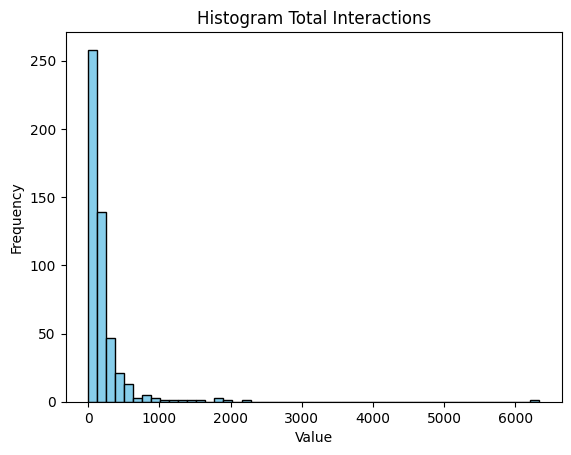

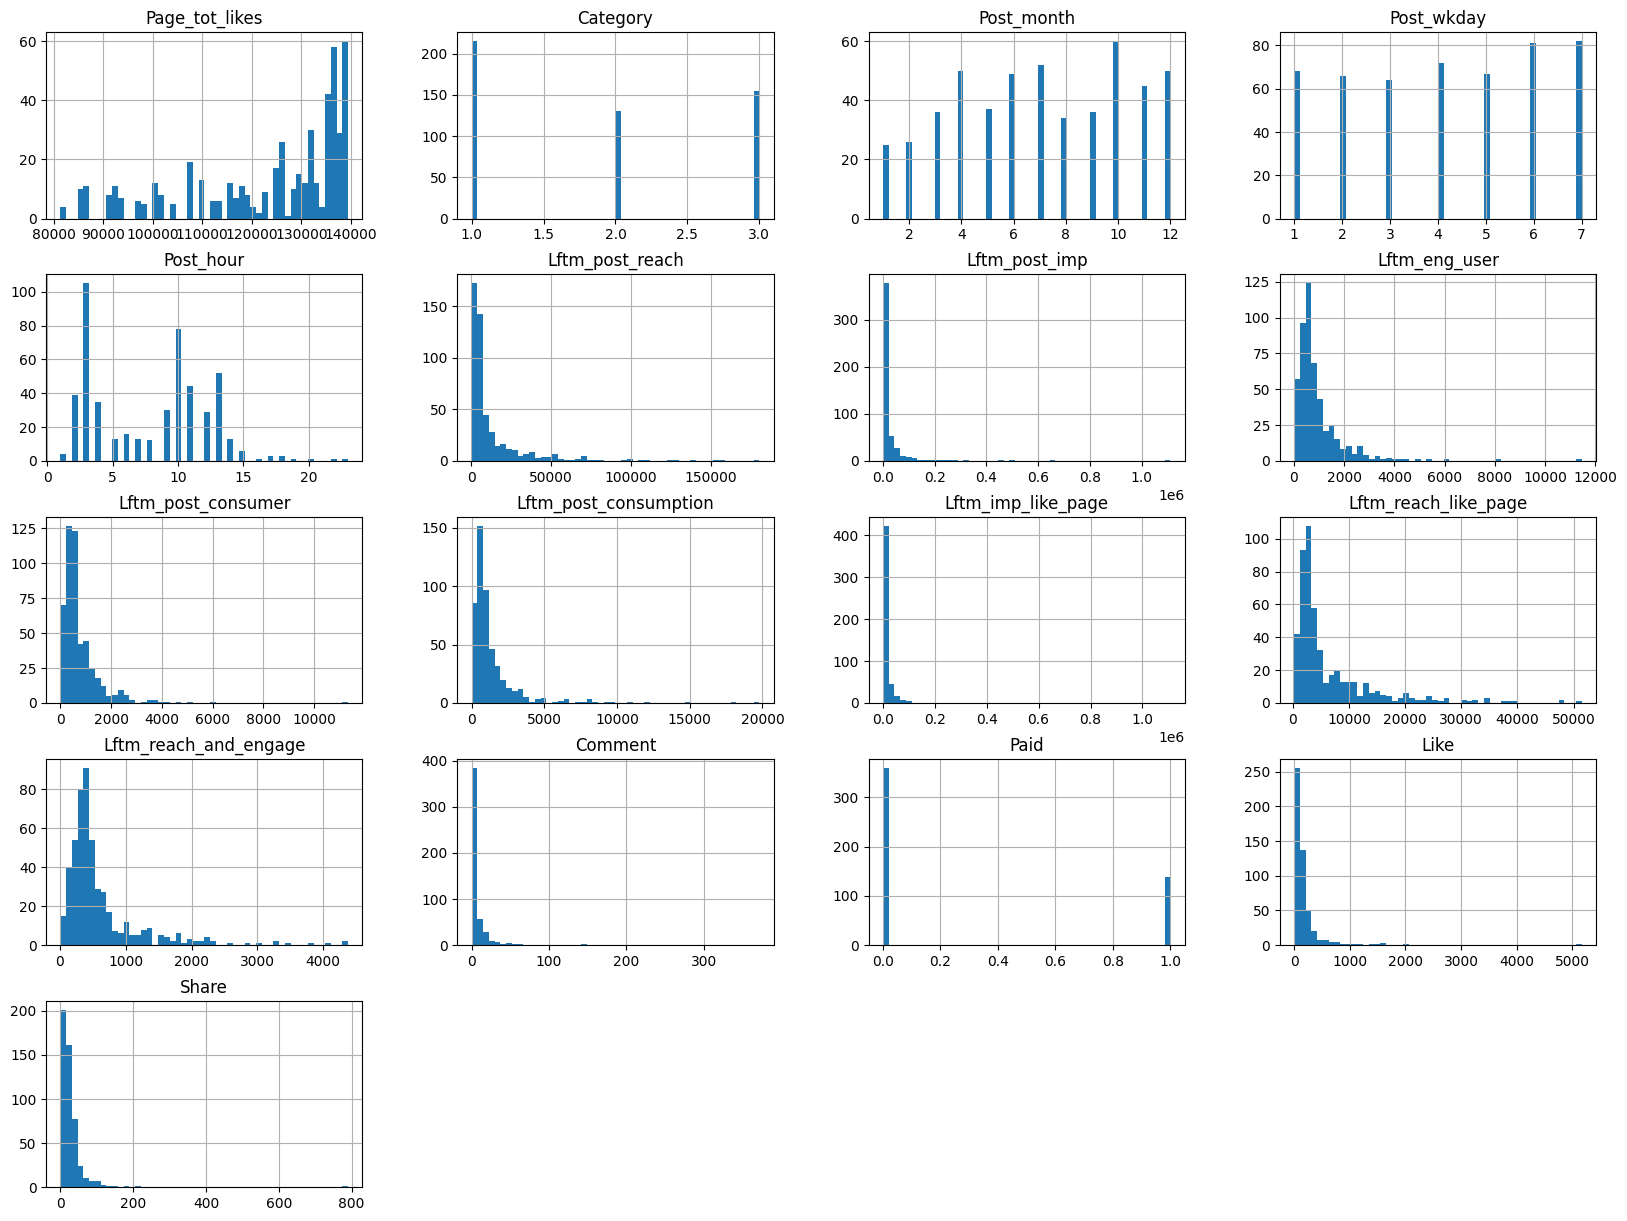

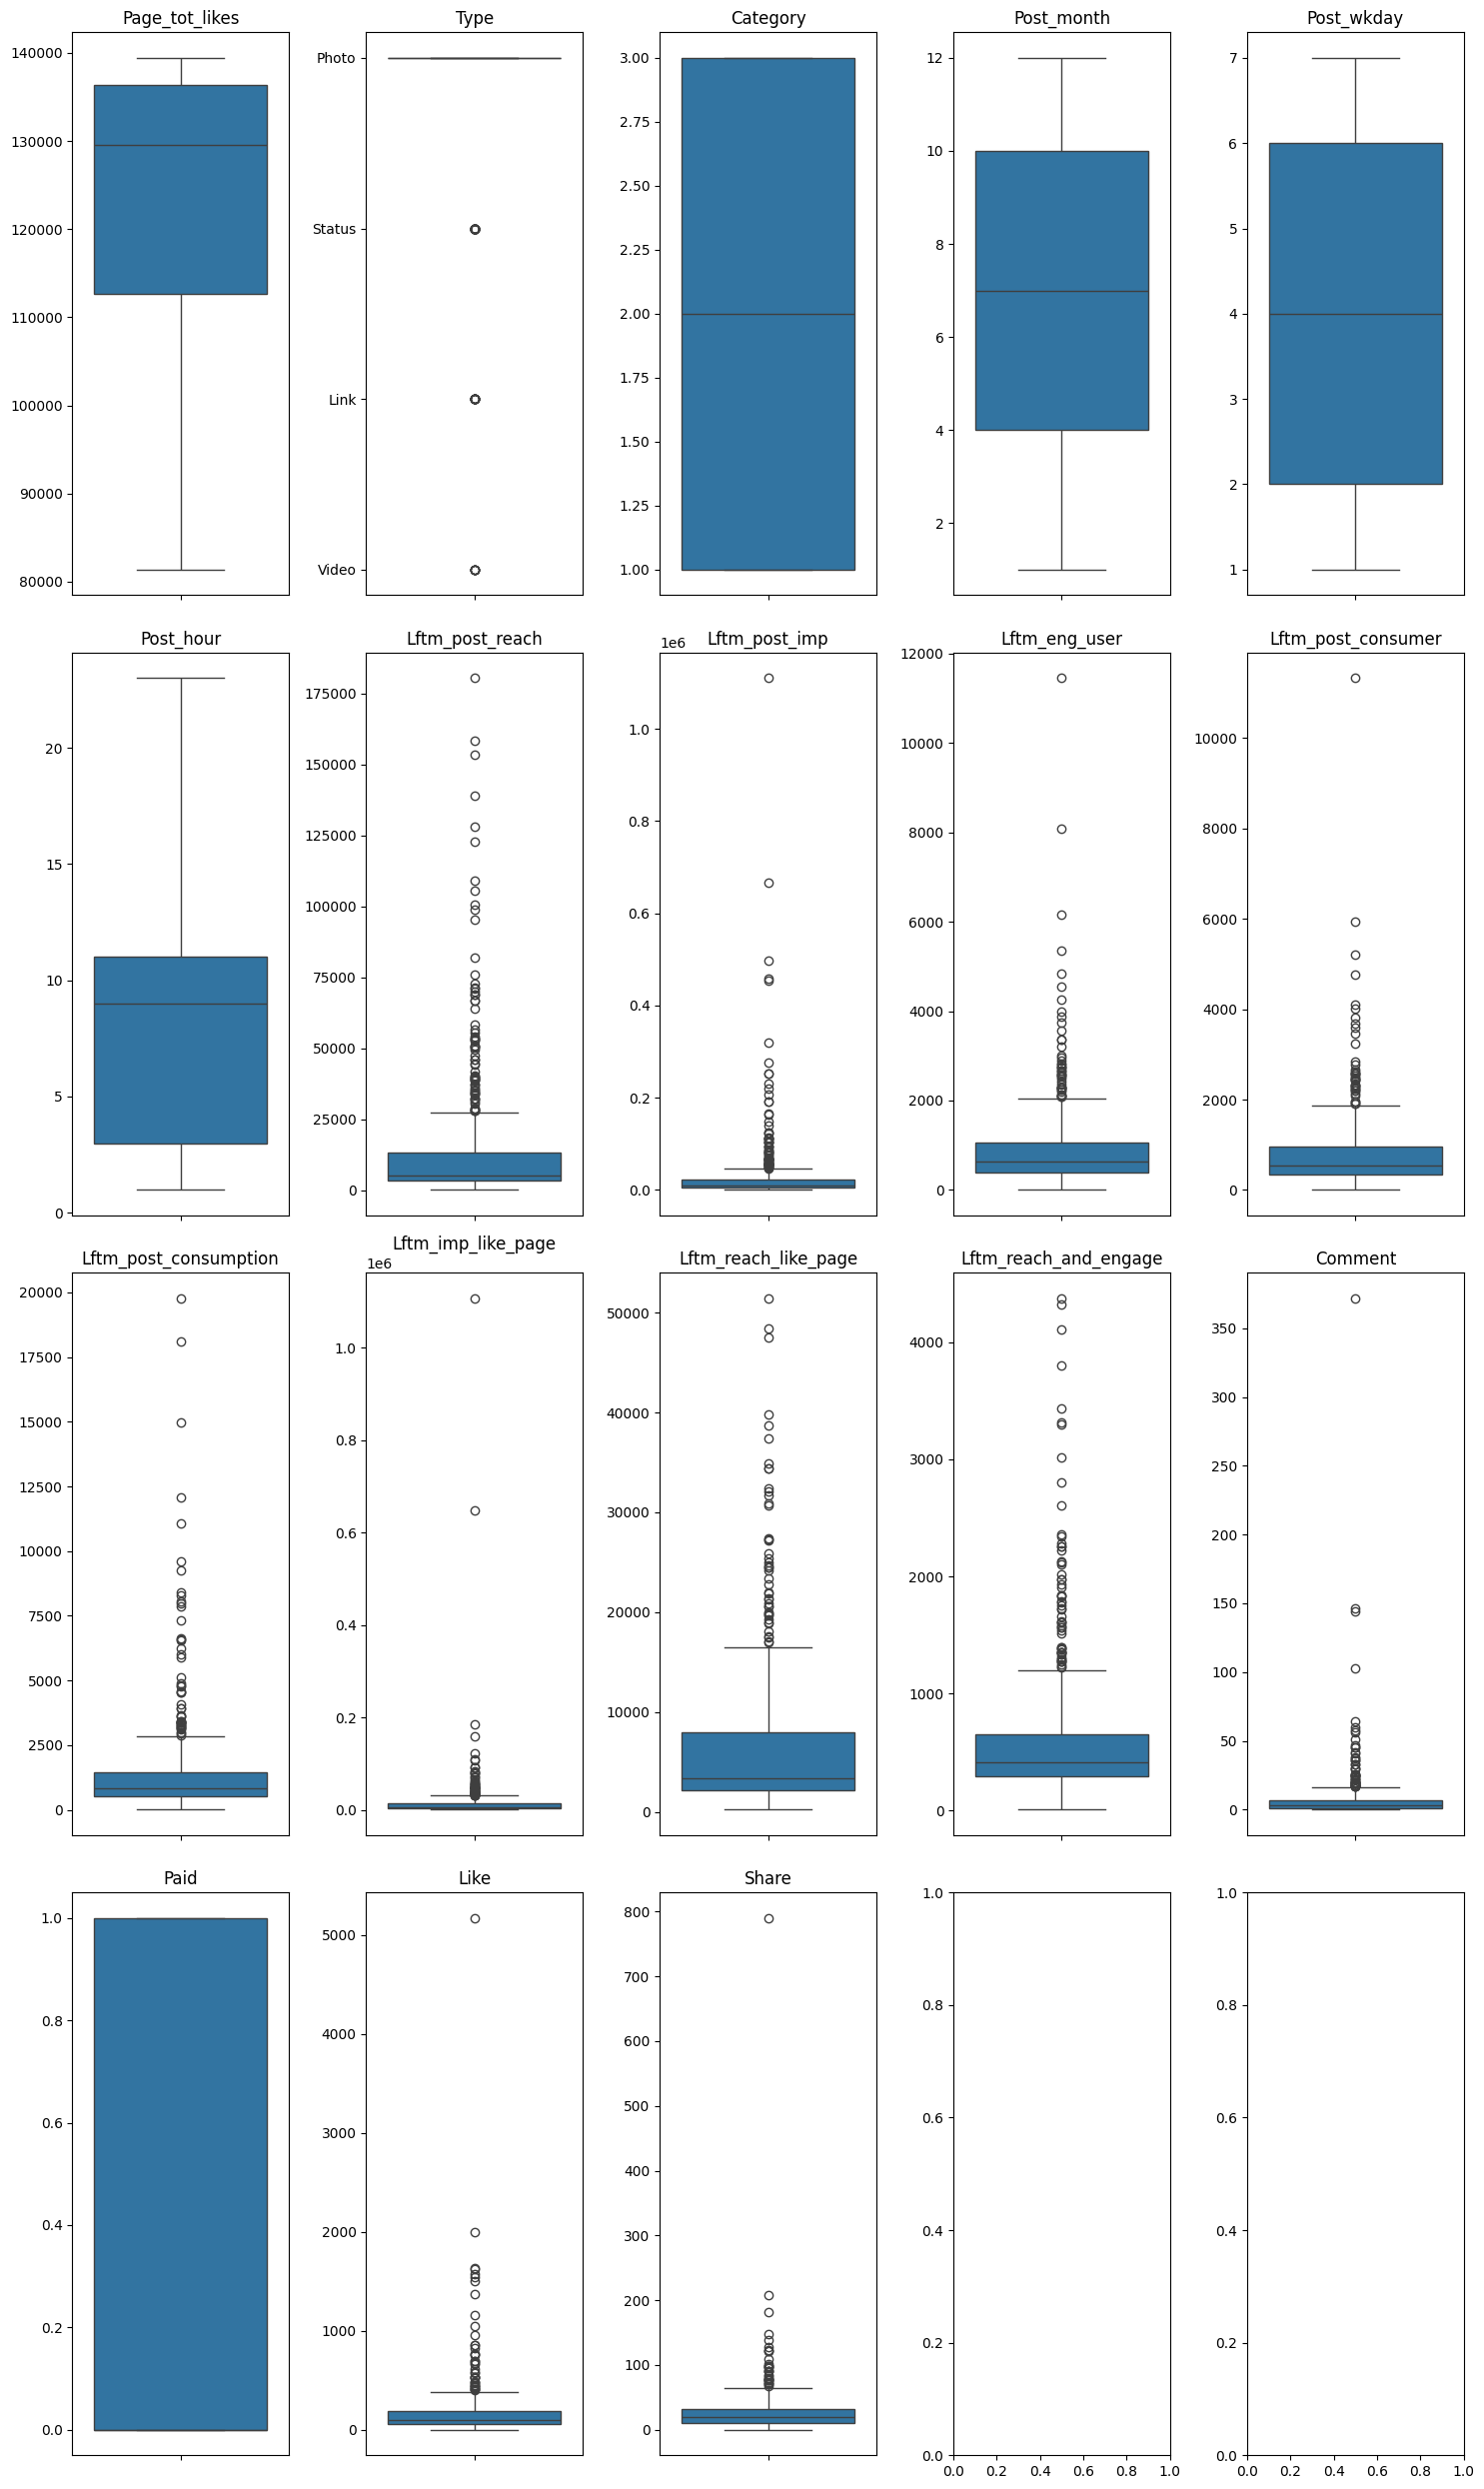

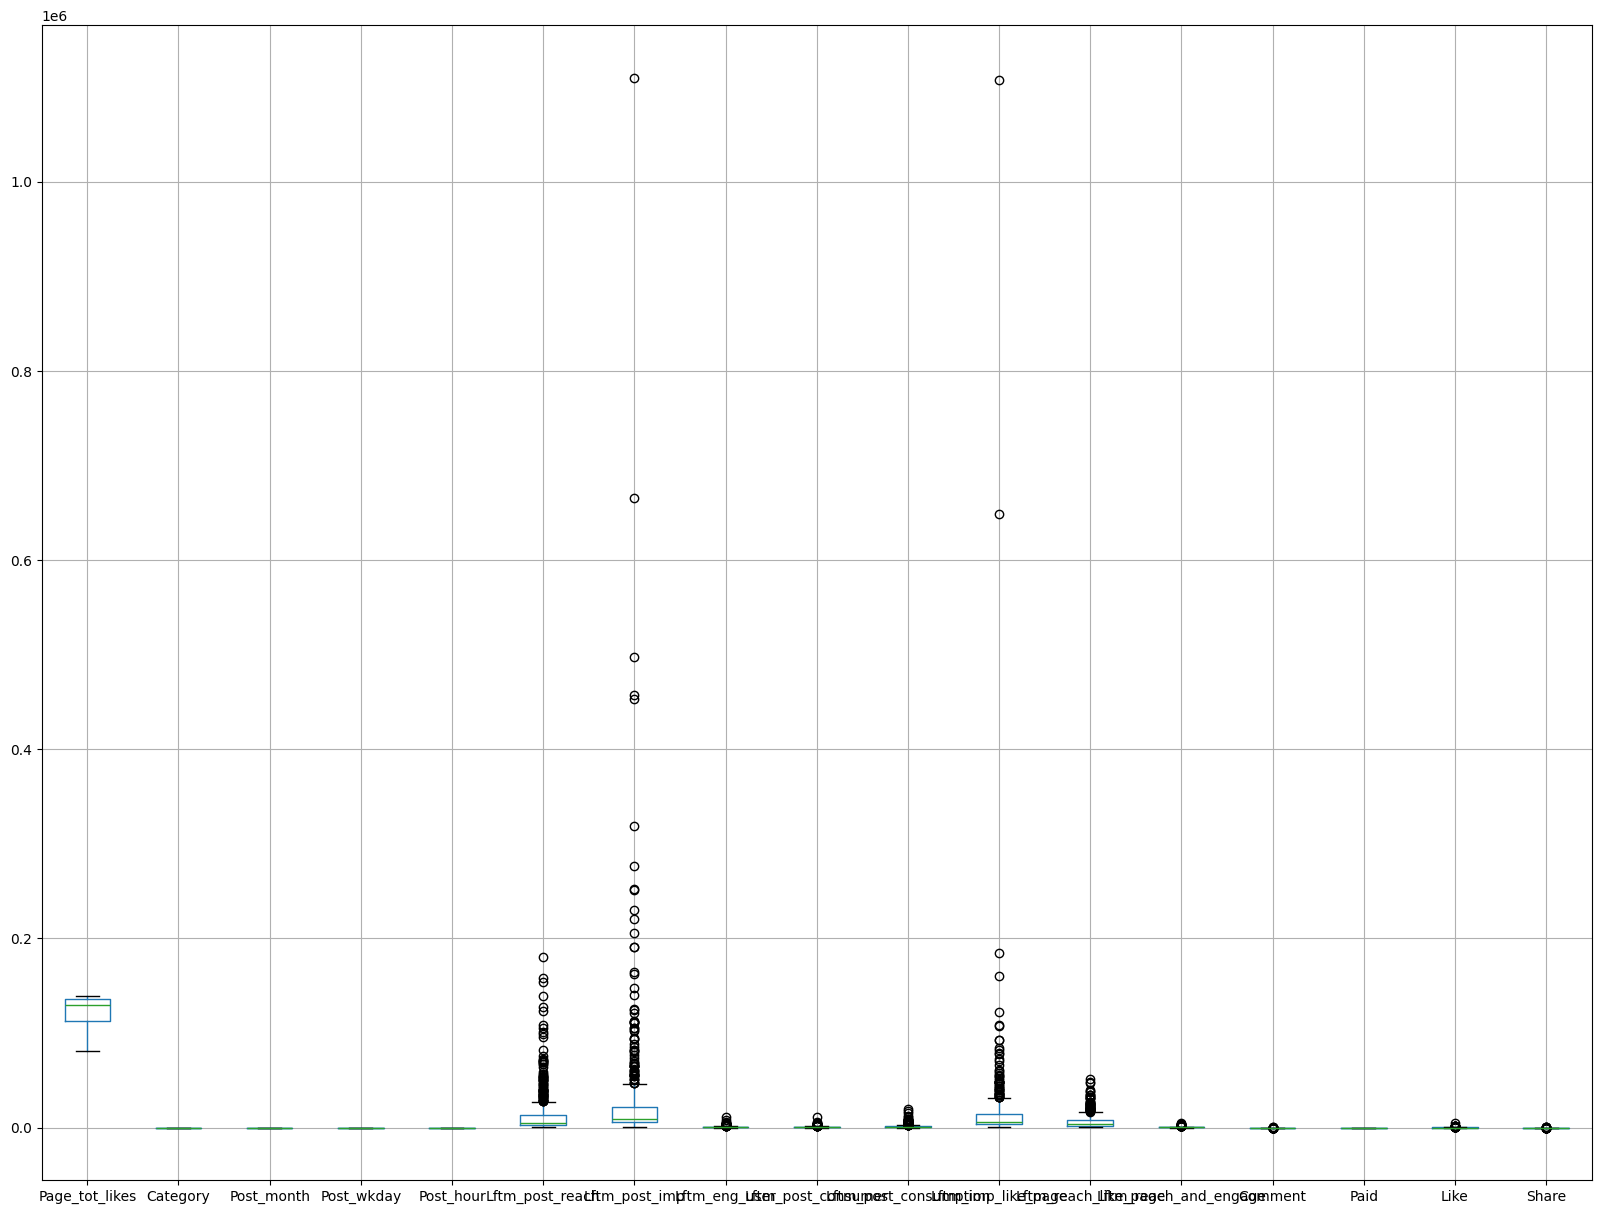

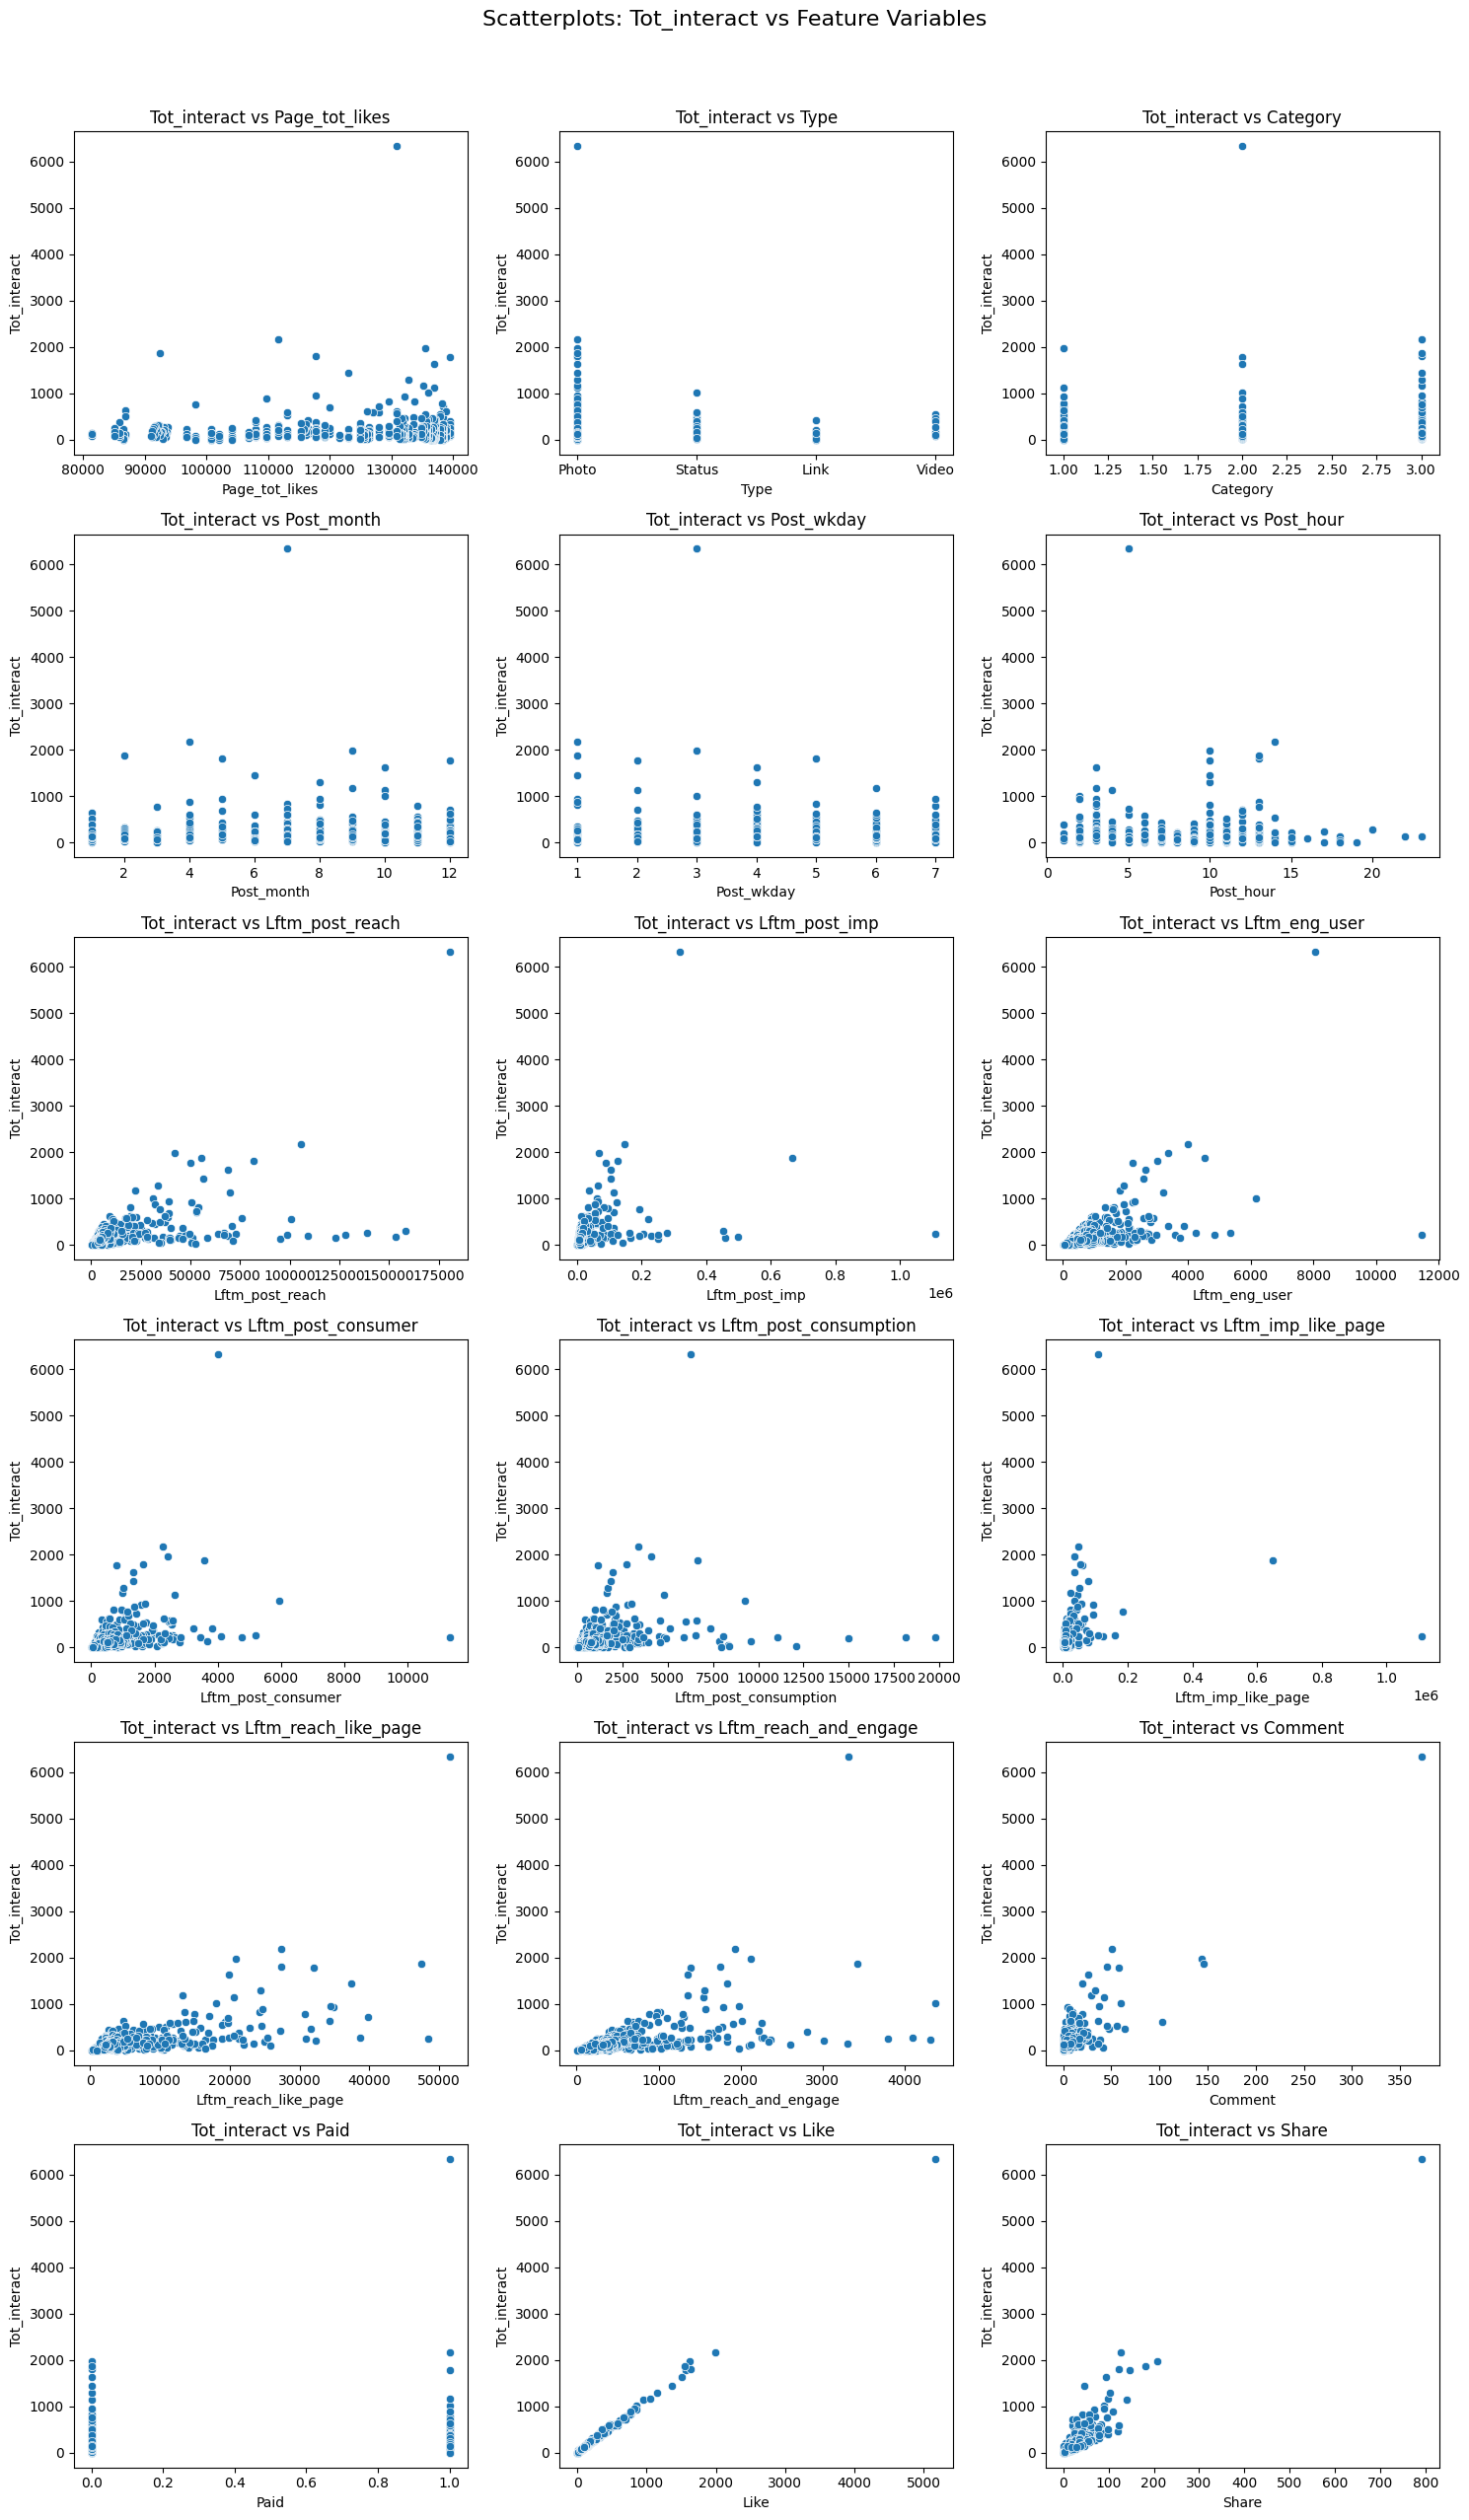

In [2]:
# ==================================
# EXploratory Data Analysis
# ==================================

from tabulate import tabulate

# Rename specific columns
df_new = df.rename(columns={
    'Page total likes': 'Page_tot_likes', 
    'Type' : 'Type', 
    'Category' : 'Category', 
    'Post Month' : 'Post_month', 
    'Post Weekday' : 'Post_wkday',
    'Post Hour': 'Post_hour', 
    'Paid' : 'Paid', 
    'Lifetime Post Total Reach' : 'Lftm_post_reach',
    'Lifetime Post Total Impressions': 'Lftm_post_imp',
    'Lifetime Engaged Users' : 'Lftm_eng_user',
    'Lifetime Post Consumers': 'Lftm_post_consumer', 
    'Lifetime Post Consumptions' : 'Lftm_post_consumption',
    'Lifetime Post Impressions by people who have liked your Page': 'Lftm_imp_like_page',
    'Lifetime Post reach by people who like your Page' : 'Lftm_reach_like_page',
    'Lifetime People who have liked your Page and engaged with your post' : 'Lftm_reach_and_engage',
    'comment' : 'Comment', 
    'like' : 'Like', 
    'share' : 'Share',
    'Total Interactions': 'Tot_interact'
})

print(f'Original df info {df.info()}\n\n')
print(f'Renamed df info {df_new.info()}\n\n')

# Exploratory analysis

# Correlation analysis between target and features

# Discrete/ continuous variables (integers only, high cardinality)
feature_vars = [
    'Page_tot_likes',  
    'Type',        
    'Category',           
    'Post_month',      
    'Post_wkday',           
    'Post_hour',          
    'Lftm_post_reach',      
    'Lftm_post_imp',      
    'Lftm_eng_user',        
    'Lftm_post_consumer',  
    'Lftm_post_consumption',   
    'Lftm_imp_like_page',
    'Lftm_reach_like_page',    
    'Lftm_reach_and_engage', 
    'Comment',
    'Paid',
    'Like',
    'Share'
]

target_var = 'Tot_interact'  # Changed from list to string

float_vars = [
    'Paid',
    'Like',
    'Share'
]

cat_vars = [
    'Type'
]

# Create a list of variables to study the correlations between variables

cont_vars = [
    'Page_tot_likes',      
    'Category',           
    'Post_month',      
    'Post_wkday',           
    'Post_hour',          
    'Lftm_post_reach',      
    'Lftm_post_imp',      
    'Lftm_eng_user',        
    'Lftm_post_consumer',  
    'Lftm_post_consumption',   
    'Lftm_imp_like_page',
    'Lftm_reach_like_page',    
    'Lftm_reach_and_engage', 
    'Comment',
    'Paid',
    'Like',
    'Share',
    'Tot_interact'
]
print(f'Categorical variables value counts:\n {df_new[cat_vars].value_counts()}')  # Added parentheses to value_counts

# ===========================
# Get descriptives 
# ===========================

# TArget variable
print(f' Total interactions descriptives \n {df_new['Tot_interact'].describe()}')

# Generate descriptive statistics
# Features
print(f'Feature Descrip[tives\n')

summary_desc_df = df_new[feature_vars].describe()

# Print the resulting DataFrame (which is in a grid/table format)
print(summary_desc_df)

# ==================================================
# Correlation Coefficients on continuous variables
# ==================================================

# Get all continuous variablessummary_desc_df = df_new[feature_vars].describe()
df_corr = df_new[cont_vars]

# ==============================================
# Charts
# ==============================================

# Examine the Target Variable, Total_Interactions
# Histogram
plt.hist(df_new['Tot_interact'], bins=50, color='skyblue', edgecolor='black')

# Add labels and a title
plt.title('Histogram Total Interactions')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()                          # Display the plot

# ===================================
# Histogram of the features
# =====================================
 
# we use the .hist() pandas function here for the more compact view
# we can accomplish the same with plt.subplots, sns.distplot() and a few extra lines of code
df_new.loc[:,  feature_vars].hist(bins=50, figsize=(20,15))
# df_explore.loc[:, discrete_vars + continuous_vars].hist(bins=50, figsize=(20,15))
plt.show()

# ===================================
# Create boxplots of the features
# =====================================

# Define the grid dimensions
n_rows = 4
n_cols = 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 25)) # Adjust figsize as needed
#fig.suptitle(f'Scatterplots: {target_var} vs Feature Variables', fontsize=16, y=1.02) # Add a title

# A simple way to use subplots with seaborn:
# fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 8)) # 2 rows, 5 columns
axes = axes.flatten() # Flatten the 2x5 array of axes into a 1D array

for i, col in enumerate(df_new[feature_vars].columns):
    sns.boxplot(y=df_new[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel('') # Optional: remove default y-axis label

plt.tight_layout()
plt.show()

# we use the .hist() pandas function here for the more compact view
df_new.loc[:,  feature_vars].boxplot(figsize=(20,15))
plt.show()


#=========================================
# Capture the correlations
# ===========================================

# Define the variable names
# target_var_name = 'main_variable'
# target_var_name = 'Tot_interact'
# feature_vars = [f'feature_{i}' for i in range(1, 19)]

# Define the grid dimensions
n_rows = 6
n_cols = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 25)) # Adjust figsize as needed
fig.suptitle(f'Scatterplots: {target_var} vs Feature Variables', fontsize=16, y=1.02) # Add a title

# Flatten the axes array to iterate easily
axes_flat = axes.flatten()

# Loop through all feature variables and plot
for i, feature in enumerate(feature_vars):
    ax = axes_flat[i]
    # Use seaborn for a clean scatterplot
    sns.scatterplot(data=df_new, x=feature, y=target_var, ax=ax)
    ax.set_title(f'{target_var} vs {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel(target_var)

# If you have fewer than 18 plots (unlikely here, but good practice), turn off extra axes
for j in range(i + 1, len(axes_flat)):
    fig.delaxes(axes_flat[j])

# Adjust layout to prevent titles/labels from overlapping
plt.tight_layout()
plt.show()


In [3]:
from tabulate import tabulate
summary_desc_df.style.format(precision=2).background_gradient(cmap='PuBu')

,Page_tot_likes,Category,Post_month,Post_wkday,Post_hour,Lftm_post_reach,Lftm_post_imp,Lftm_eng_user,Lftm_post_consumer,Lftm_post_consumption,Lftm_imp_like_page,Lftm_reach_like_page,Lftm_reach_and_engage,Comment,Paid,Like,Share
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,499.00,499.00,496.00
mean,123194.18,1.88,7.04,4.15,7.84,13903.36,29585.95,920.34,798.77,1415.13,16766.38,6585.49,609.99,7.48,0.28,177.95,27.27
std,16272.81,0.85,3.31,2.03,4.37,22740.79,76803.25,985.02,882.51,2000.59,59791.02,7682.01,612.73,21.18,0.45,323.40,42.61
min,81370.00,1.00,1.00,1.00,1.00,238.00,570.00,9.00,9.00,9.00,567.00,236.00,9.00,0.00,0.00,0.00,0.00
25%,112676.00,1.00,4.00,2.00,3.00,3315.00,5694.75,393.75,332.50,509.25,3969.75,2181.50,291.00,1.00,0.00,56.50,10.00
50%,129600.00,2.00,7.00,4.00,9.00,5281.00,9051.00,625.50,551.50,851.00,6255.50,3417.00,412.00,3.00,0.00,101.00,19.00
75%,136393.00,3.00,10.00,6.00,11.00,13168.00,22085.50,1062.00,955.50,1463.00,14860.50,7989.00,656.25,7.00,1.00,187.50,32.25
max,139441.00,3.00,12.00,7.00,23.00,180480.00,1110282.00,11452.00,11328.00,19779.00,1107833.00,51456.00,4376.00,372.00,1.00,5172.00,790.00


In [4]:
# Present correlations in a table
# print(f'Correlation Matrix of Continuous Variables\n {df_corr.corr()}')
corr_matrix = df_corr.corr()

# Displays the table with a background color gradient based on values
corr_matrix.style.background_gradient(cmap='coolwarm')

,Page_tot_likes,Category,Post_month,Post_wkday,Post_hour,Lftm_post_reach,Lftm_post_imp,Lftm_eng_user,Lftm_post_consumer,Lftm_post_consumption,Lftm_imp_like_page,Lftm_reach_like_page,Lftm_reach_and_engage,Comment,Paid,Like,Share,Tot_interact
Page_tot_likes,1.000000,-0.091142,0.941192,-0.005401,-0.143807,-0.083245,-0.102540,-0.111922,-0.149129,-0.128240,-0.096109,-0.060516,0.033699,0.031891,0.005341,0.053276,-0.004859,0.045231
Category,-0.091142,1.000000,-0.127690,-0.053239,-0.107383,-0.142073,-0.094368,0.003392,-0.031172,-0.149443,-0.047803,-0.104456,0.021569,0.027842,-0.022474,0.126786,0.149211,0.127307
Post_month,0.941192,-0.127690,1.000000,0.017050,-0.176390,-0.102506,-0.101616,-0.115898,-0.147083,-0.142829,-0.094624,-0.092012,0.010956,0.006174,-0.018934,0.025633,-0.021859,0.018362
Post_wkday,-0.005401,-0.053239,0.017050,1.000000,0.045857,-0.050155,-0.033674,-0.048382,-0.029602,-0.021565,-0.046442,-0.068741,0.001144,-0.077209,-0.001963,-0.082322,-0.048713,-0.081049
Post_hour,-0.143807,-0.107383,-0.176390,0.045857,1.000000,0.003338,0.012747,0.003879,0.012222,0.078759,0.038892,0.052412,0.038011,0.000922,-0.069464,-0.024523,-0.058680,-0.027421
Lftm_post_reach,-0.083245,-0.142073,-0.102506,-0.050155,0.003338,1.000000,0.694926,0.570629,0.477908,0.324362,0.322254,0.743053,0.400756,0.427155,0.146631,0.545185,0.456312,0.538597
Lftm_post_imp,-0.102540,-0.094368,-0.101616,-0.033674,0.012747,0.694926,1.000000,0.368553,0.315201,0.226081,0.850787,0.651933,0.323843,0.316612,0.062564,0.345091,0.286829,0.343358
Lftm_eng_user,-0.111922,0.003392,-0.115898,-0.048382,0.003879,0.570629,0.368553,1.000000,0.968213,0.676840,0.260346,0.612080,0.839279,0.505806,0.117014,0.569565,0.531261,0.572159
Lftm_post_consumer,-0.149129,-0.031172,-0.147083,-0.029602,0.012222,0.477908,0.315201,0.968213,1.000000,0.706666,0.222941,0.503847,0.813510,0.334621,0.097679,0.349152,0.343048,0.354502
Lftm_post_consumption,-0.128240,-0.149443,-0.142829,-0.021565,0.078759,0.324362,0.226081,0.676840,0.706666,1.000000,0.164813,0.355389,0.577262,0.261195,0.097462,0.235634,0.201300,0.238082


## Selecting a Model for the Facebook Data


__Data Science Algorithms selected for building models to predict values of a coninuous variable.__


#### Statistical Algorithms

* __OLS___  Basic OLS Regression

* __Ridge Regression:__ Adds an L2 penalty, which shrinks coefficients toward zero.

#### Machine Learning Algorithms

__Ensemble Methods:__ Algorithms combine the predictions of multiple simpler models to improve accuracy and reduce overfitting:

* __Random Forest:__ Builds multiple decision trees during training and outputs the average of the individual predictions for the final result.

* __Gradient Boosting (e.g., abroost, LightGBM, CatBoost):__ Builds trees sequentially, with each new tree correcting the errors made by previous ones, resulting in a highly accurate model.

In [5]:
# ==============================
# Preprocessing pipeline
# ==============================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, FunctionTransformer

discrete_vars = [
    'Category',
    'Post_month',
    'Post_wkday',    
    'Post_hour'     
]

cat_vars = [
    'Type'
]

continuous_vars = [
    'Page_tot_likes',
    'Paid',
    'Lftm_post_reach',
    'Lftm_post_imp',
    'Lftm_eng_user',
    'Lftm_post_consumer',
    'Lftm_post_consumption',
    'Lftm_imp_like_page', 
    'Lftm_reach_like_page',
    'Lftm_reach_and_engage', 
    'Comment',
    'Like',
    'Share'
]

"""
# 'Like', 'Comments' and 'share' are components of total interaction so we are removing
# them from the analysis to prevent overfitting
"""

continuous_vars = [
    'Page_tot_likes',
    'Paid',
    'Lftm_post_reach',
    'Lftm_post_imp',
    'Lftm_eng_user',
    'Lftm_post_consumer',
    'Lftm_post_consumption',
    'Lftm_imp_like_page', 
    'Lftm_reach_like_page',
    'Lftm_reach_and_engage', 
]

bin_vars = ['Type_Link',
            'Type_Photo',
            'Type_Status',
            'Type_Video'
]

target_var = 'Tot_interact'  # Changed from list to string

# Categorical - impute, one hot encode
cat_si_step = ('si', SimpleImputer(strategy='constant', fill_value='Other'))
cat_ohe_step = ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
cat_steps = [cat_si_step, cat_ohe_step]
cat_pipe = Pipeline(cat_steps)
cat_transformers = [('cat', cat_pipe, cat_vars)]

# Numerical - scale
num_si_step = ('si', SimpleImputer(strategy='median')) # Replace missing Paid value with a simple median
num_scl_step = ('scl', StandardScaler())
num_steps = [num_si_step, num_scl_step]
num_pipe = Pipeline(num_steps)
num_transformers = [('num', num_pipe, discrete_vars + continuous_vars)]

print(f'Preprocessing complete')
df_new

Preprocessing complete


,Page_tot_likes,Type,Category,Post_month,Post_wkday,Post_hour,Paid,Lftm_post_reach,Lftm_post_imp,Lftm_eng_user,Lftm_post_consumer,Lftm_post_consumption,Lftm_imp_like_page,Lftm_reach_like_page,Lftm_reach_and_engage,Comment,Like,Share,Tot_interact
0,139441,Photo,2,12,4,3,0.0,2752,5091,178,109,159,3078,1640,119,4,79.0,17.0,100
1,139441,Status,2,12,3,10,0.0,10460,19057,1457,1361,1674,11710,6112,1108,5,130.0,29.0,164
2,139441,Photo,3,12,3,3,0.0,2413,4373,177,113,154,2812,1503,132,0,66.0,14.0,80
3,139441,Photo,2,12,2,10,1.0,50128,87991,2211,790,1119,61027,32048,1386,58,1572.0,147.0,1777
4,139441,Photo,2,12,2,3,0.0,7244,13594,671,410,580,6228,3200,396,19,325.0,49.0,393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,85093,Photo,3,1,7,2,0.0,4684,7536,733,708,985,4750,2876,392,5,53.0,26.0,84
496,81370,Photo,2,1,5,8,0.0,3480,6229,537,508,687,3961,2104,301,0,53.0,22.0,75
497,81370,Photo,1,1,5,2,0.0,3778,7216,625,572,795,4742,2388,363,4,93.0,18.0,115
498,81370,Photo,3,1,4,11,0.0,4156,7564,626,574,832,4534,2452,370,7,91.0,38.0,136


In [6]:
#========================================
# Create a DataFrame with All Features
# ======================================

df_ml = df_new.copy()
df_ml.columns
# df_ml_all_features = df_ml[[target_var] + fe_binary_vars + fe_grouped_vars + og_integer_vars]
df_ml_all_features = df_ml[[target_var] + discrete_vars + continuous_vars + cat_vars]

print(f' Features BEFORE missing values handled {df_ml_all_features.info()}\n')

# =======================================================================================================
# OLD CODE -- This was used to replace one missing value in the 'Paid variable with the mean.
# This is no longer needed since I'm now using the SipleImputer in the preprocessing pipeline to fix this
# =======================================================================================================

# The 'Paid' column has one missing value so I'm replacing that missing value with the mean
# df_ml['Paid'] = df_ml['Paid'].fillna(df_ml['Paid'].mean())

df_ml_all_features = df_ml[[target_var] + discrete_vars + continuous_vars]

print(f' Features AFTER missing values handled {df_ml_all_features.info()}\n')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Tot_interact           500 non-null    int64  
 1   Category               500 non-null    int64  
 2   Post_month             500 non-null    int64  
 3   Post_wkday             500 non-null    int64  
 4   Post_hour              500 non-null    int64  
 5   Page_tot_likes         500 non-null    int64  
 6   Paid                   499 non-null    float64
 7   Lftm_post_reach        500 non-null    int64  
 8   Lftm_post_imp          500 non-null    int64  
 9   Lftm_eng_user          500 non-null    int64  
 10  Lftm_post_consumer     500 non-null    int64  
 11  Lftm_post_consumption  500 non-null    int64  
 12  Lftm_imp_like_page     500 non-null    int64  
 13  Lftm_reach_like_page   500 non-null    int64  
 14  Lftm_reach_and_engage  500 non-null    int64  
 15  Type  

In [7]:

# ================================================
# Create train and test datasets for all models
# ===================================================
from sklearn.preprocessing import OneHotEncoder

# Include ordinal_vars in fit and transform
# all_features = cat_vars + discrete_vars + continuous_vars
all_features =  discrete_vars + continuous_vars + cat_vars

# ct = ColumnTransformer(transformers=cat_transformers + num_transformers, remainder='passthrough')
ct = ColumnTransformer(transformers=num_transformers + cat_transformers, remainder='passthrough')
ct.fit(df_ml[all_features])
X = ct.transform(df_ml[all_features])
y = df_ml[target_var].values

# train test split

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

X_df = pd.DataFrame(X)
print('x_inf\n')
print(f'{X_df.info()}')
print('List of features \n')
print(f' {df_ml[all_features].info()}')

print(f'Test train setup complete.')

# Returns a combined table of counts for the last 4 columns
X_df.iloc[:, -4:].apply(pd.Series.value_counts)  # print value counts for the first four categories
print(f' df_ml {df_ml}')
print(f' X_df {X_df}')



# Use the ColumnTransformer's inverse_transform method instead of undefined 'encoder'
# Note: inverse_transform may not work perfectly with ColumnTransformer containing mixed transformers
try:
    X_restored = ct.inverse_transform(X_df)
    print("Inverse transformation successful")
except Exception as e:
    print(f"Inverse transformation failed: {e}")
    print("Consider using the original dataframe or individual transformer inverse methods")


(400, 18) (100, 18) (400,) (100,)
x_inf

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       500 non-null    float64
 1   1       500 non-null    float64
 2   2       500 non-null    float64
 3   3       500 non-null    float64
 4   4       500 non-null    float64
 5   5       500 non-null    float64
 6   6       500 non-null    float64
 7   7       500 non-null    float64
 8   8       500 non-null    float64
 9   9       500 non-null    float64
 10  10      500 non-null    float64
 11  11      500 non-null    float64
 12  12      500 non-null    float64
 13  13      500 non-null    float64
 14  14      500 non-null    float64
 15  15      500 non-null    float64
 16  16      500 non-null    float64
 17  17      500 non-null    float64
dtypes: float64(18)
memory usage: 70.4 KB
None
List of features 

<class 'pandas.core.frame.DataFrame'>
RangeIndex

### Machine Learning Models 
* Random Forest
* XGBoost
* Adaboost


In [8]:
# ======================================================
# RANDOM FOREST GRID SEARCH
# ======================================================
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

param_grid = {
    'n_estimators': [4, 5, 10, 20, 50],
    'max_depth':	[None, 10, 20, 30],	# Prevent overfitting
    'min_samples_leaf':	[1, 2, 4, 10]	# Control overfitting
    # 'bootstrap':	[True, False]	# Sampling method,  BOOTSTRAP RESULT: DID NOT MAKE ANY DIFFERENCE
}

# Create base classifier with class_weight
# rf = RandomForestClassifier(random _state=0, class_weight='balanced')
# rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf = RandomForestRegressor(random_state=42)
 
# Create GridSearchCV with recall scoring (important for imbalanced data!)
grid_search_rf = GridSearchCV(
    rf, 
    param_grid, 
    cv=5,
    # scoring='recall' # important for imbalanced data!
)

# Fit the grid search
grid_search_rf.fit(X_train, y_train)

# 5. Make predictions
y_pred_rfr = grid_search_rf.predict(X_test)

# 6. Evaluate the model
r2_rfr = r2_score(y_test, y_pred_rfr)
mse_rfr = mean_squared_error(y_test, y_pred_rfr)
rmse_rfr = np.sqrt(mse_rfr)

print(f'X_train shape {X_train.shape}')
print(f'y_train shape {y_train.shape}\n')

# Model diagnostics

print(f'R-Square {r2_rfr}\n')
print(f'y min: {np.min(y)}, max: {np.max(y)}, mean: {np.mean(y)}, std: {np.std(y)}\n')
print(f'mse: {mse_rfr} rmse: {rmse_rfr}\n')
# mse and rmse

# Get the best model
best_rf = grid_search_rf.best_estimator_

# See what parameters were best
print(f"Best parameters: {grid_search_rf.best_params_}\n")
# print(f"Best CV recall score: {grid_search.best_score_:.3f}")

print(f'Random Forest model setup complete.')

X_train shape (400, 18)
y_train shape (400,)

R-Square -0.08474466995460683

y min: 0, max: 6334, mean: 212.12, std: 379.85269460673834

mse: 58764.45562181316 rmse: 242.41381070766815

Best parameters: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 50}

Random Forest model setup complete.


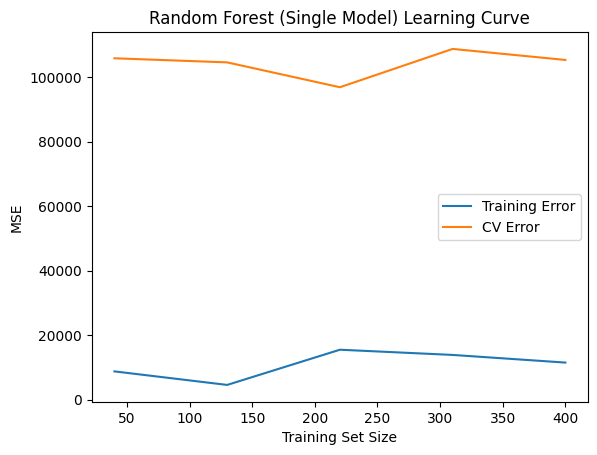

In [9]:
# ==============================
# RANDOM FOREST LEARNING CURVE
# ==============================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import learning_curve
from sklearn.datasets import make_regression

# 1. Generate data and define model
# X, y = make_regression(n_samples=500, n_features=10, random_state=42)
# estimator = RandomForestRegressor(random_state=42)

# 2. Compute learning curve scores

train_sizes, train_scores, validation_scores = learning_curve(
   rf, X, y, cv=5, scoring='neg_mean_squared_error', n_jobs=-1
)
# 3. Plot results (negating scores to get MSE)
plt.plot(train_sizes, -train_scores.mean(axis=1), label="Training Error")
plt.plot(train_sizes, -validation_scores.mean(axis=1), label="CV Error")
plt.xlabel("Training Set Size")
plt.ylabel("MSE")
plt.title(f"Random Forest (Single Model) Learning Curve")
plt.legend()
plt.show()

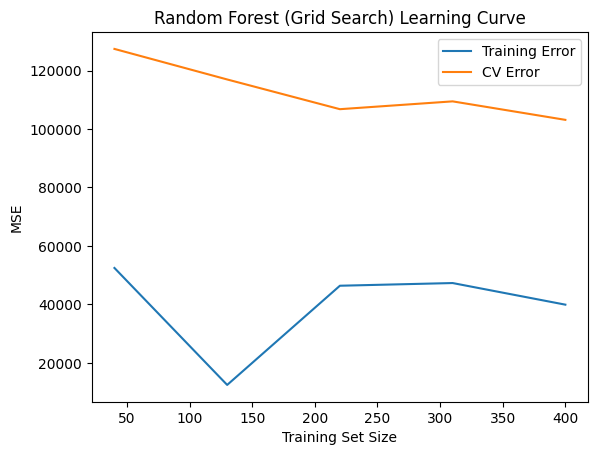

In [10]:
# =============================================
# RANDOM FOREST LEARNING CURVE GRID SEARCH CV
# =============================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import learning_curve
from sklearn.datasets import make_regression

# 1. Generate data and define model
# X, y = make_regression(n_samples=500, n_features=10, random_state=42)
# estimator = RandomForestRegressor(random_state=42)

# 2. Compute learning curve scores
"""
train_sizes, train_scores, validation_scores = learning_curve(
   rf, X, y, cv=5, scoring='neg_mean_squared_error', n_jobs=-1
)
"""
train_sizes, train_scores, validation_scores = learning_curve(
   grid_search_rf, X, y, cv=5, scoring='neg_mean_squared_error', n_jobs=-1
)

# 3. Plot results (negating scores to get MSE)
plt.plot(train_sizes, -train_scores.mean(axis=1), label="Training Error")
plt.plot(train_sizes, -validation_scores.mean(axis=1), label="CV Error")
plt.xlabel("Training Set Size")
plt.ylabel("MSE")
plt.title(f"Random Forest (Grid Search) Learning Curve")
plt.legend()
plt.savefig('Random Forest Grid Search Learning Curve.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# ======================================================
# XGBOOST
# ======================================================

import numpy as np
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42  # Adding random_state for reproducibility
)

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}

# Initialize GridSearchCV
grid_search_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
    n_jobs=-1
)

print("Training the model...")
# Fit the grid search
grid_search_xgb.fit(X_train, y_train)
print("Model training complete.")

# Make predictions on the test set
y_pred_xgb = grid_search_xgb.predict(X_test)

# Evaluate the model
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

# Get the best fitted model from GridSearchCV
best_xgb = grid_search_xgb.best_estimator_
# best_features_xgb = grid_search_xgb.best_estimator_.feature_importances_
print(f'X_train shape {X_train.shape}')
print(f'y_train shape {y_train.shape}\n')

# Best features list
best_features_xgb = list(zip(df_ml[all_features].columns, grid_search_xgb.best_estimator_.feature_importances_))

# Model Evaluation
print(f"\nModel Evaluation:")
print(f'R-Square {r2_xgb}\n')
 
# mse and rmse
print(f'y min: {np.min(y)}, max: {np.max(y)}, mean: {np.mean(y)}, std: {np.std(y)}')
print(f'mse: {mse_xgb} rmse: {rmse_xgb}\n')

# Get and print the best model -- see what parameters were best
print(f'Best model {best_xgb}\n')
print(f"Best parameters xgb: {grid_search_xgb.best_params_}")
print(f'best features {best_features_xgb}\n')

print(f'XGBoost model setup complete.')

Training the model...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Model training complete.
X_train shape (400, 18)
y_train shape (400,)


Model Evaluation:
R-Square 0.6382192373275757

y min: 0, max: 6334, mean: 212.12, std: 379.85269460673834
mse: 19598.943359375 rmse: 139.99622623262027

Best model XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.2, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimat

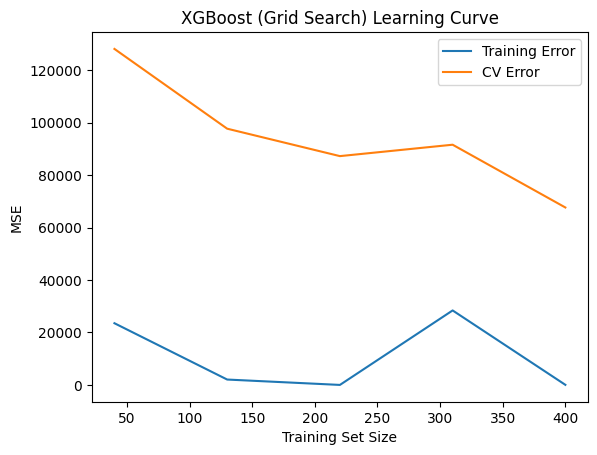

In [12]:
# ==============================
# XGBOOST LEARNING CURVE
# ==============================

# 1. Generate data and define model
# X, y = make_regression(n_samples=500, n_features=10, random_state=42)
# estimator = RandomForestRegressor(random_state=42)

# 2. Compute learning curve scores

train_sizes, train_scores, validation_scores = learning_curve(
   grid_search_xgb, X, y, cv=5, scoring='neg_mean_squared_error', n_jobs=-1
)
# 3. Plot results (negating scores to get MSE)
plt.plot(train_sizes, -train_scores.mean(axis=1), label="Training Error")
plt.plot(train_sizes, -validation_scores.mean(axis=1), label="CV Error")
plt.xlabel("Training Set Size")
plt.ylabel("MSE")
plt.title(f"XGBoost (Grid Search) Learning Curve")
plt.legend()
plt.savefig('XGBoost Grid Search Learning Curve.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

### ADABOOST

In AdaBoost regression models, the primary hyperparameters for tuning are the number of estimators, the learning rate, 
the base estimator (weak learner), and the loss function.   
The key hyperparameters available in the scikit-learn implementation of AdaBoostRegressor include:   
__n_estimators:__ This defines the maximum number of weak learners (models) to train sequentially. Increasing the number of estimators can improve performance, but also increases training time and may lead to overfitting after a certain point.  
__learning_rate:__ This controls the contribution of each weak learner to the final prediction. Smaller learning rates require a larger number of estimators to achieve the same performance, but can lead to a more robust model and better performance.  
__base_estimator:__ This is the underlying algorithm used as the weak learner. By default, a decision tree with a maximum depth of 1 (a "decision stump") is used because it is simple and effective. You can specify a different regressor, but it must support sample weights. The hyperparameters of the base estimator itself (e.g., max_depth for a decision tree) can also be tuned for better results.  
__loss:__ This specifies the loss function to use when updating the weights after each iteration. Scikit-learn's AdaBoostRegressor offers 'linear', 'square', and 'exponential' options, each affecting how the errors of the predictions are penalized.   
Tuning these hyperparameters often involves using techniques like grid search or random search to find the optimal combination for a specific dataset.   

In [13]:
# =================================================
# ADABOOST
# =================================================

# Import necessary libraries if not already imported
from sklearn.impute import SimpleImputer
import numpy as np
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Handle missing values using SimpleImputer
# Create an imputer object that replaces NaN values with the mean of the column
imputer = SimpleImputer(strategy='mean')

# Fit the imputer on the training data and transform both training and test data
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Initialize the AdaBoost Regressor
abr = AdaBoostRegressor(random_state=42)

# Define the grid of hyperparameters to search
param_grid_abr = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 1.0],
    'loss': ['linear', 'square', 'exponential']
}

# Setup the GridSearchCV
grid_search_abr = GridSearchCV(
    estimator=abr,
    param_grid=param_grid_abr,
    scoring='neg_mean_absolute_error',
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Fit the GridSearchCV to the imputed training data
grid_search_abr.fit(X_train, y_train)

# Make predictions on the imputed test set
y_pred_abr = grid_search_abr.predict(X_test)

# Evaluate the model
mse_abr = mean_squared_error(y_test, y_pred_abr)
rmse_abr = np.sqrt(mse_abr)
r2_abr = r2_score(y_test, y_pred_abr)

# Model Evaluation
print(f"\nModel Evaluation:")
print(f'R-Square {r2_abr}\n')
 
# mse and rmse
print(f'y min: {np.min(y)}, max: {np.max(y)}, mean: {np.mean(y)}, std: {np.std(y)}')
print(f'mse: {mse_abr} rmse: {rmse_abr}\n')

# Output the best parameters found
print(f"Best parameters found: {grid_search_abr.best_params_}")

# You can then use the best estimator to make predictions
best_model_abr = grid_search_abr.best_estimator_
predictions_abr = best_model_abr.predict(X_test)

print(f' Adaboost model complete.')

Fitting 5 folds for each of 27 candidates, totalling 135 fits

Model Evaluation:
R-Square 0.5031943148639739

y min: 0, max: 6334, mean: 212.12, std: 379.85269460673834
mse: 26913.72121520743 rmse: 164.0540191985781

Best parameters found: {'learning_rate': 0.01, 'loss': 'exponential', 'n_estimators': 50}
 Adaboost model complete.


 X features columns RangeIndex(start=0, stop=18, step=1) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       500 non-null    float64
 1   1       500 non-null    float64
 2   2       500 non-null    float64
 3   3       500 non-null    float64
 4   4       500 non-null    float64
 5   5       500 non-null    float64
 6   6       500 non-null    float64
 7   7       500 non-null    float64
 8   8       500 non-null    float64
 9   9       500 non-null    float64
 10  10      500 non-null    float64
 11  11      500 non-null    float64
 12  12      500 non-null    float64
 13  13      500 non-null    float64
 14  14      500 non-null    float64
 15  15      500 non-null    float64
 16  16      500 non-null    float64
 17  17      500 non-null    float64
dtypes: float64(18)
memory usage: 70.4 KB
 X info None 



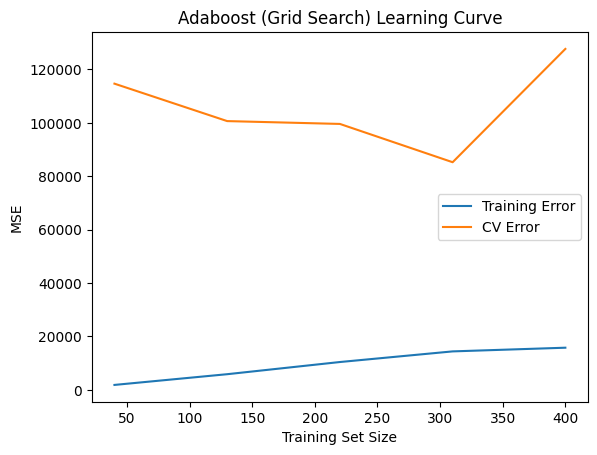

In [14]:
# ====================================
# ADABOOST REGRESSION LEARNING CURVE
# ====================================

# To identify why there are missing values in the features dataframe(X)
# 2. List the columns in the dataframe
# 2. Lookt at which columns have missing values

# 1. Generate data and define model
# X, y = make_regression(n_samples=500, n_features=10, random_state=42)
# estimator = RandomForestRegressor(random_state=42)

# Check if X is a numpy array and convert to DataFrame if needed
if isinstance(X, np.ndarray):
    # Convert numpy array to DataFrame
    X = pd.DataFrame(X)

print(f' X features columns {X.columns} \n')
print(f' X info {X.info()} \n')

# 2. Compute learning curve scores
# X_transform = X.fillna(X.mean())

train_sizes, train_scores, validation_scores = learning_curve(
   grid_search_abr, X, y, cv=5, scoring='neg_mean_squared_error', n_jobs=-1 
)
# 3. Plot results (negating scores to get MSE)
plt.plot(train_sizes, -train_scores.mean(axis=1), label="Training Error")
plt.plot(train_sizes, -validation_scores.mean(axis=1), label="CV Error")
plt.xlabel("Training Set Size")
plt.ylabel("MSE")
plt.title(f"Adaboost (Grid Search) Learning Curve")
plt.legend()
plt.savefig('ADABoost Grid Search Learning Curve.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()


## Statistical Techniques
* OLS
* Ridge Regression


In [15]:
# OLS - statsmodels

import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Split data into training and testing sets
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Add constant term for intercept
X_train_with_const = sm.add_constant(X_train)
X_test_with_const = sm.add_constant(X_test)

# Fit OLS model
model_sm = sm.OLS(y_train, X_train_with_const).fit()

# Print model summary
print(f' Model Summary {model_sm.summary()}\n')

# Make predictions
y_pred_sm = model_sm.predict(X_test_with_const)

# Evaluate the model
mse_sm = mean_squared_error(y_test, y_pred_sm)
rmse_sm = np.sqrt(mse_sm)
r2_sm = r2_score(y_test, y_pred_sm)

print(f"\nModel Performance on Test Set:")
print(f"R-squared Score: {r2_sm:.4f}")

# mse and rmse
print(f'y min: {np.min(y)}, max: {np.max(y)}, mean: {np.mean(y)}, std: {np.std(y)}')
print(f'mse: {mse_sm} rmse: {rmse_sm}\n')

print(f' OLS statsmodels complete.')

 Model Summary                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.975
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     870.5
Date:                Mon, 06 Jul 2026   Prob (F-statistic):          3.12e-293
Time:                        13:10:47   Log-Likelihood:                -2235.6
No. Observations:                 400   AIC:                             4507.
Df Residuals:                     382   BIC:                             4579.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        198.3929      7.859     

In [16]:
# OLS - sklearn
# On untransformed dependent variable

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# Check if X is a numpy array and convert to DataFrame if needed
if isinstance(X, np.ndarray):
    # Convert numpy array to DataFrame
    X = pd.DataFrame(X)
    
# X_transform = X.fillna(X.mean())
 
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,        # 20% for testing, 80% for training
    random_state=42       # for reproducibility
)

# Create and train the OLS model (LinearRegression in sklearn)
model_ols = LinearRegression()
model_ols.fit(X_train, y_train)

# Make predictions on the test set
y_pred_ols = model_ols.predict(X_test)

# Evaluate the model
mse_ols = mean_squared_error(y_test, y_pred_ols)
rmse_ols = np.sqrt(mse_ols)
r2_ols = r2_score(y_test, y_pred_ols)

print(f'y min: {np.min(y)}, max: {np.max(y)}, mean: {np.mean(y)}, std: {np.std(y)}')
print(f'mse: {mse_ols} rmse: {rmse_ols}\n')

print(f"R-squared Score: {r2_ols:.4f}")


# View model coefficients
print("\nOLS Model Coefficients:")
print(f"Intercept: {model_ols.intercept_:.4f}")
if hasattr(X, 'columns'):  # If X is a DataFrame with column names
    for feature, coef in zip(X.columns, model_ols.coef_):
        print(f"{feature}: {coef:.4f}")
else:
    print(f"Coefficients: {model_ols.coef_}")

# ===============================================================
# To determine overfitting, compare the r2 on train and test sets
# ================================================================

# Make predictions on both training and test data
y_train_pred = model_ols.predict(X_train)
y_test_pred = model_ols.predict(X_test)   # same as y_pred_ols

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"R-squared on training data (r2_score): {r2_train:.2f}")
# print(f"R-squared on training data (model.score): {r2_train_model_score:.2f}")
print(f"R-squared on test data (r2_score): {r2_test:.2f}")
# print(f"R-squared on test data (model.score): {r2_test_model_score:.2f}")


y min: 0, max: 6334, mean: 212.12, std: 379.85269460673834
mse: 7865.1669173328255 rmse: 88.68577629661267

R-squared Score: 0.8548

OLS Model Coefficients:
Intercept: 247.9912
0: -3.9380
1: -43.1697
2: -1.6023
3: -6.6727
4: 25.5190
5: -6.0099
6: -32.6308
7: 37.7403
8: 1465.4234
9: -1301.9601
10: 9.0387
11: 8.8907
12: -34.2556
13: 40.5454
14: -6.1300
15: -34.2541
16: -50.4234
17: 90.8074
R-squared on training data (r2_score): 0.97
R-squared on test data (r2_score): 0.85


### Ridge Regression

Ridge regression is implemented in the scikit-learn library via the sklearn.linear_model.Ridge class, which performs linear least squares regression with L2 regularization. This technique is used to prevent overfitting and handle multicollinearity in data by adding a penalty to the size of the model's coefficients. 
Key Features and Parameters

The primary parameters for the Ridge class are:
alpha: This is a float value (or array-like) that controls the strength of the L2 regularization penalty (λ in mathematical notation).

Larger alpha values increase the regularization strength, shrinking coefficients more heavily towards zero (but never exactly to zero), which increases bias but reduces variance.
Setting alpha = 0 is equivalent to ordinary least squares (standard linear regression), though using the LinearRegression object is recommended in that case for numerical reasons.

fit_intercept: A boolean (default True) that specifies whether to calculate the intercept for the model.
normalize: A boolean (deprecated since version 1.2, use a StandardScaler instead) which, if True, preprocesses the input features X by subtracting the mean and dividing by the L2 norm before regression.
solver: Automatically chooses the solver based on data type, but options like 'svd', 'cholesky', 'lsqr', 'sag', and 'saga' are available for different computational performance profiles, especially for large datasets. 


Using grid search cross-validation to optimize the hyperparameters of a Ridge Regression model in Python [1]. The scikit-learn library provides robust tools for this purpose [1, 2]. 

How to use Grid Search with Ridge Regression
The process typically involves using Ridge from the linear_model module and GridSearchCV from the model_selection module in scikit-learn [1, 2]. 

Here is a general outline of the steps:
Import necessary libraries: Import Ridge, GridSearchCV, and other utilities like make_pipeline for potential preprocessing [1, 2].
Instantiate the Ridge Regression model: Create an instance of the Ridge class [1, 2].
Define the hyperparameter grid: Specify a dictionary of the hyperparameters you want to tune and the range of values to explore. For Ridge Regression, the primary hyperparameter to optimize is alpha (the regularization strength) [1, 2].

Instantiate GridSearchCV: Create an instance of GridSearchCV, passing the Ridge model, the hyperparameter grid, the number of cross-validation folds (cv), and a scoring metric (e.g., 'neg_mean_squared_error', 'r2') [1, 2].

Fit the model: Use the .fit() method of the GridSearchCV instance on your training data. This process trains the Ridge model multiple times for every combination of hyperparameters defined in the grid, using cross-validation for evaluation [1, 2].

Retrieve the best parameters: After fitting, you can access the best-found alpha value using the .best_params_ attribute and the best model using .best_estimator_ [1]. 

In [17]:
# =====================================
# Ridge Regression
# =====================================

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# using Grid Search to cross validate and optimize parameters

# 1. Instantiate the Ridge model
ridge_rr = Ridge()

# 2. Define the hyperparameter grid for alpha
param_grid_rr = {'alpha': [0.1, 1.0, 10.0, 100.0]}

# 3. Instantiate GridSearchCV
# cv=3 specifies 3-fold cross-validation
# scoring='r2' can be changed to other metrics like 'neg_mean_squared_error'
grid_search_rr = GridSearchCV(estimator=ridge_rr, param_grid=param_grid_rr, cv=3, scoring='r2')

# 4. Fit the model to find the best hyperparameters
grid_search_rr.fit(X_train, y_train)

# Make predictions on the imputed test set
y_pred_rr = grid_search_rr.predict(X_test)

# Evaluate the model
mse_rr = mean_squared_error(y_test, y_pred_rr)
rmse_rr = np.sqrt(mse_rr)
r2_rr = r2_score(y_test, y_pred_rr)

# Model Evaluation
print(f"\nModel Evaluation:")
print(f'R-Square {r2_rr}\n')
 
# mse and rmse
print(f'y min: {np.min(y)}, max: {np.max(y)}, mean: {np.mean(y)}, std: {np.std(y)}')
print(f'mse: {mse_rr} rmse: {rmse_rr}\n')

# 5. Retrieve the best parameters
print(f"Best parameters found: {grid_search_rr.best_params_}")
print(f"Best R-squared score found: {grid_search_rr.best_score_}\n")

# Ridge Regression Coefficients

print('List of features \n')
print(f' {df_ml[all_features].info()}')

# View model coefficients
print("\nRidge Model Coefficients:")  # Fixed comment to match Ridge Regression
print(f"Intercept: {grid_search_rr.best_estimator_.intercept_:.4f}")  # Access through best_estimator_
if hasattr(X, 'columns'):  # If X is a DataFrame with column names
    for feature, coef in zip(X.columns, grid_search_rr.best_estimator_.coef_):  # Access through best_estimator_
        print(f"{feature}: {coef:.4f}")
else:
    print(f"Coefficients: {grid_search_rr.best_estimator_.coef_}")  # Access through best_estimator_


# Use the best estimator for future predictions
best_model_rr = grid_search_rr.best_estimator_
# predictions_rr = best_model_rr.predict(X_test)
predictions_rr = grid_search_rr.predict(X_test)

print(f' best estimator \n {best_model_rr}')

print('Ridge Regression complete.')



Model Evaluation:
R-Square 0.8563907666449976

y min: 0, max: 6334, mean: 212.12, std: 379.85269460673834
mse: 7779.820131059782 rmse: 88.20328866351743

Best parameters found: {'alpha': 0.1}
Best R-squared score found: 0.8943031120115509

List of features 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Category               500 non-null    int64  
 1   Post_month             500 non-null    int64  
 2   Post_wkday             500 non-null    int64  
 3   Post_hour              500 non-null    int64  
 4   Page_tot_likes         500 non-null    int64  
 5   Paid                   499 non-null    float64
 6   Lftm_post_reach        500 non-null    int64  
 7   Lftm_post_imp          500 non-null    int64  
 8   Lftm_eng_user          500 non-null    int64  
 9   Lftm_post_consumer     500 non-null    int64  
 10  Lftm_p

### Residual v. Predicted Value Check

Plot the residuals v. the predicted values to obtain a visual reference for fitting the predicted values v. the residuals. 

The chart below, plotting residuals against predicted values, shows a cluster that is relatively constant around the zero point,  i.e. not curved, indicating a relatively linear relationship between predicted and actual values.

The cluster appears to be relatively random around the zero line, indicating constant variance (little homoskeaticity), enabling better prediction.

Plotting residuals vs. predicted (fitted) values is one of the most meaningful and essential diagnostics you can perform for an Ordinary Least Squares (OLS) model. It provides an immediate visual check for several key assumptions of linear regression:

Homoscedasticity: It reveals if the variance of the errors is constant across all levels of the predicted values. A funnel shape (widening or narrowing) indicates non-constant variance (heteroscedasticity).

Linearity: It highlights whether the relationship between the predictors and the outcome is truly linear. A curved pattern in the residuals suggests the model is missing important non-linear terms or transformations.

Outliers: It makes it easy to spot extreme data points or influential outliers that deviate significantly from the rest of the residual spread.

In a well-fitting OLS model, the residuals should appear as a completely random, shapeless cloud of points centered symmetrically around the \(0\) line.To learn more about interpreting these plots, check out the regression diagnostic guides on Statistics by Jim or the University of Virginia Library.


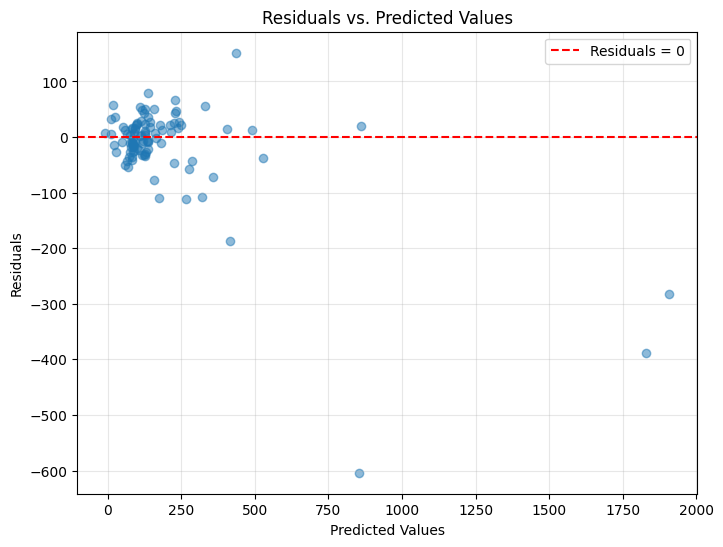

In [18]:
# Plot residuals against predicted values

# For scikit-learn GridSearchCV, calculate residuals manually
predictions_rr = grid_search_rr.predict(X_test)
residuals_rr = y_test - predictions_rr  # Calculate residuals manually: actual - predicted

# Create the plot
plt.figure(figsize=(8, 6))
plt.scatter(predictions_rr, residuals_rr, alpha=0.5)  
plt.axhline(y=0, color='red', linestyle='--', label="Residuals = 0")
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.legend()
plt.grid(True, alpha=0.3)
# Save as SVG
plt.savefig('Residuals vs. Predicted Values.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()



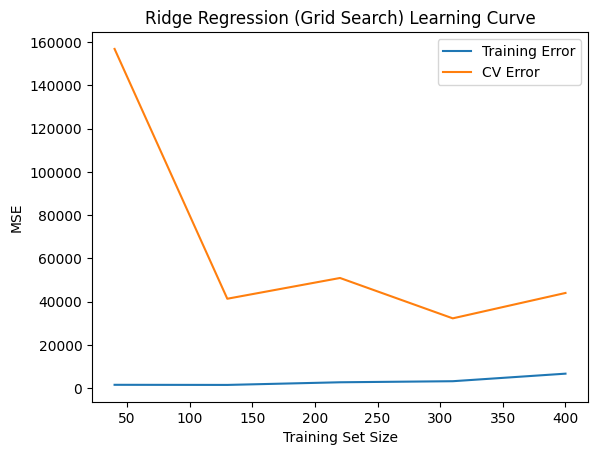

In [19]:
# ==============================
# RIDGE REGRESSION LEARNING CURVE
# ==============================


# To identify why there are missing values in the features dataframe(X)
# 2. List the columns in the dataframe
# 2. Lookt at which columns have missing values

# 1. Generate data and define model
# X, y = make_regression(n_samples=500, n_features=10, random_state=42)
# estimator = RandomForestRegressor(random_state=42)

# Check if X is a numpy array and convert to DataFrame if needed
if isinstance(X, np.ndarray):
    # Convert numpy array to DataFrame
    X = pd.DataFrame(X)

# print(f' X features columns {X.columns} \n')
# print(f' X info {X.info()} \n')

# 2. Compute learning curve scores
# X_transform = X.fillna(X.mean())

train_sizes, train_scores, validation_scores = learning_curve(
   grid_search_rr, X, y, cv=5, scoring='neg_mean_squared_error', n_jobs=-1 
)
# 3. Plot results (negating scores to get MSE)
plt.plot(train_sizes, -train_scores.mean(axis=1), label="Training Error")
plt.plot(train_sizes, -validation_scores.mean(axis=1), label="CV Error")
plt.xlabel("Training Set Size")
plt.ylabel("MSE")
plt.title(f"Ridge Regression (Grid Search) Learning Curve")
plt.legend()
plt.savefig('Ridge Regression Grid Search Learning Curve.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()


### Summary of Findings

_Performance Metrics_

| Model | Random Forest| XGBoost | ADABoost | OLS | Ridge Regression |
| :-------- | :--------: | :--------: | :--------: | :--------: | :--------: |
| R-Square |-0.005| 0.638| 0.501 |0.975 |0.89 |
| MSE|58764  |19500  |26913|7865| 7779|
| RMSE|242.4 |140.0 |164.1|88.7 | 88.2|

Standard deviaion of the target variable: 379.9 





### Change Log
v4_GH04 - Residual map  
v4_GH05 - unnecessary comments removed; prep for redeployment on GitHub
v4_GH06 - cleaned up markdowns and comments for posting to GitHub